# Supervised Probabilistic PCA (SPPCA) with ARD for AML / ALL / Normal Classification


## Table of Contents

1. [Introduction](#introduction)  
2. [Loading & Preprocessing Data](#data-loading-preprocessing)  
3. [Visualizing Data](#presentingdata)
3. [Supervised PPCA (SPPCA) with ARD](#model-definition-ppca-with-ard)
4. [Training SPPCA with SVI](#training_SPPCA)
5. [Inspecting ARD Parameter](#plotting_ARD)  
6. [Inspecting Latent Space](#inspecting_latent_space)  
7. [Performing Classification on Test Data](#classi_test)  
8. [Performing Classification on Validation Data](#classi_val)  
9. [Visualizing Feature Importance](#feature_importance)

**Data**: Extracted from https://portal.gdc.cancer.gov/analysis_page?app=CohortBuilder&tab=general, loaded in to chunks of 70% train, 15% validation, 15% test using our custom Chunkloader.py script, and stored as three csv files.


**Preprocessing**: Using the function `load_and_preprocess()` data is loaded and preprocessed dropping non-numeric gene-expression values. Additional Z-score normalization and clipping of outliers is applied to the data.

**Modelling**: A Supervised Probabilistic PCA (SPPCA) model is defined to learn a latent space `z`. The size of the latent space is regulated by Automatic Relevance Detection (ARD). Besides dimensionality reduction of the data into latent space, the model is extended with labeled data thus making the model supervised and allowing for classification of the data into AML, ALL, and Normal classes.

**Classification**: General classification parameters `A` and `b` are inferred from the training data under supervision, while a new latent space `z` is inferred unsupervised from the relevant data one whishes to classify. Classification is performed using `Argmax` on the logits `A @ z + b`.

**Feature Importance (gene importance)**: A feature importance module is used to rank the genes based on their contribution to reduce the observed space to the latent space through `W`, as well as the contribution of each gene to the classification task through `A`. From this, the top genes are selected for with possible further analysis.

**Execution**: The notebook is designed to be run using the large dataset of 5.787 subjects each with 60.660 gene expressions. This is executed on a High Performance Computing (HPC) server hosted by DTU Computing Center. The code is run through a BASH job script located on Thinlinc.






Created by:
- Julius Lunde Søgaard (s201709)
- Kalle Jan Gustav Falk (s214766)
- Richard Borodin Schmidt (s214806)
- Kristian Greve Lambertsen (s214790)

In [1]:
# IMPORTS
import time

import pandas as pd
import numpy as np
import os

import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam, Adam

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE

from featureimportance import compute_feature_importance_from_AW,plot_top_genes_from_AW,plot_all_genes_from_AW

# EXTERNAL VALUES FROM BASH SCRIPT
Toggle = os.environ.get("toggle", "small")  # Default to "small"
SVI_PPCA_n_steps = int(os.environ.get("SVI_PPCA_n_steps", 1000))  # Default to 1000
SVI_z_n_steps = int(os.environ.get("SVI_z_n_steps", 1000))  # Default to 1000
latent_dim = int(os.environ.get("latent_dim", 100))  # Default to 100


c:\Users\kgl07\anaconda3\envs\course42186\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="introduction"></a>
## Introduction

Understanding genetic profiles is crucial in cancer research because mutations and gene expression changes drive the development, progression, and response to treatment of the disease. By analyzing genetic data, we can identify biomarkers and cancer subtypes, and ideally classify cancer based on samples of gene expressions.

This notebook implements a Supervised Probabilistic PCA (SPPCA) model with Automatic Relevance Detection (ARD) for the classification of Acute Myeloid Leukemia (AML), Acute Lymphoblastic Leukemia (ALL), and Normal samples based on gene expression data. Additionally, the learned latent space will be used to identify genes that show the most significant contribution to the classification task, providing insights into the underlying biological processes.

We have chosen to use PPCA as the core of our model primarily due to its capacity to reduce the dimensionality of the observed data to a much smaller, informative latent space. Gene expression datasets often contain thousands of genes (features) measured across relatively few samples, leading to the well-known "curse of dimensionality." This high dimensionality not only increases computational burden, but can also obscure meaningful patterns due to noise and redundancy in the data.


<a id="data-loading-preprocessing"></a>
## Loading & Preprocessing Data

A toggle button has been utilized to swap between a smaller debugging dataset and the full dataset.

Debugging dataset consist of two dataset each with 200 subjects with 400 gene expressions.
Full dataset consists of three dataset one for training (4050, 60660), one for validation (869, 60660), and one for testing (868, 60660).


In [2]:
def load_small_data():
    pyro.set_rng_seed(42)

    # Load small dataset
    test_data_path = "small_test_data.csv"
    test_label_path = "small_test_labels.csv"
    test_data = pd.read_csv(test_data_path).values.astype(np.float32)
    test_label = pd.read_csv(test_label_path).values.flatten()

    val_data_path = "small_val_data.csv"
    val_label_path = "small_val_labels.csv"
    val_data = pd.read_csv(val_data_path).values.astype(np.float32)
    val_label = pd.read_csv(val_label_path).values.flatten()

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:400,0]
    gene_type = pd.read_csv(genes_path, header=None).values[:400,1]

    return test_data, test_label, val_data, val_label, gene_names, gene_type



def load_large_data():
    pyro.set_rng_seed(42)
    torch.set_num_threads(8)

    # File paths
    train_path = "/work3/s214806/working_chunk_train.csv"
    val_path = "/work3/s214806/working_chunk_val.csv"
    test_path = "/work3/s214806/working_chunk_test.csv"

    LABEL_MAPPING = {'AML': 0, 'ALL': 1, 'Normal': 2}



    # Load and preprocess data
    def load_and_preprocess(path, data_type):
        df = pd.read_csv(path, index_col=0, low_memory=False).T
        df_shape_before = df.shape[1]

        labels = df['Cancer'].map(LABEL_MAPPING).dropna()

        gene_expressions = df.drop(['Cancer', 'Preservation Method', 'Tissue Type', 'Tumor Descriptor', 'Specimen Type'], 
                                axis=1, errors='ignore')

        gene_expressions = gene_expressions.apply(pd.to_numeric, errors='coerce')
        gene_expressions = gene_expressions.dropna(axis=1)

        df_shape_after = gene_expressions.shape[1]
        print(f"{data_type} features (genes expressions) BEFORE ({df_shape_before}) and AFTER ({df_shape_after}) removing non-numeric columns")

        gene_expressions = gene_expressions.astype(np.float32)
        return gene_expressions.values, labels.loc[gene_expressions.index].values
    



    # Load your data using your function
    X_train, y_train = load_and_preprocess(train_path, "Train data")
    X_val, y_val = load_and_preprocess(val_path, "Validation data")
    X_test, y_test = load_and_preprocess(test_path, "Test data")

    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)

    print("X_val shape:", X_val.shape)
    print("y_val shape:", y_val.shape)

    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)

    genes_path = "gene_label.csv"
    gene_names = pd.read_csv(genes_path, header=None).values[:,0]
    gene_type = pd.read_csv(genes_path, header=None).values[:,1]

    return X_train, y_train, X_val, y_val, X_test, y_test, gene_names, gene_type


if Toggle == "small":
    X_train, y_train, X_val, y_val, gene_names, _ = load_small_data()
elif Toggle == "large":
    X_train, y_train, X_val, y_val, X_test, y_test, gene_names, _ = load_large_data()


<a id="presentingdata"></a>
## Visualizing data

Visializations contains:
- Class distribution (AML = 0, ALL = 1, Normal = 2) of total dataset.
- Class distribution across datasets (train, test, validation).
- Distribution of raw train data and normalized clipped train data.

Total number of subjects: 400
Total number of features: 400
Number of subjects in each class:
label
0    236
1    135
2     29
Name: count, dtype: int64


C:\Users\kgl07\AppData\Local\Temp\ipykernel_16956\2679910609.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


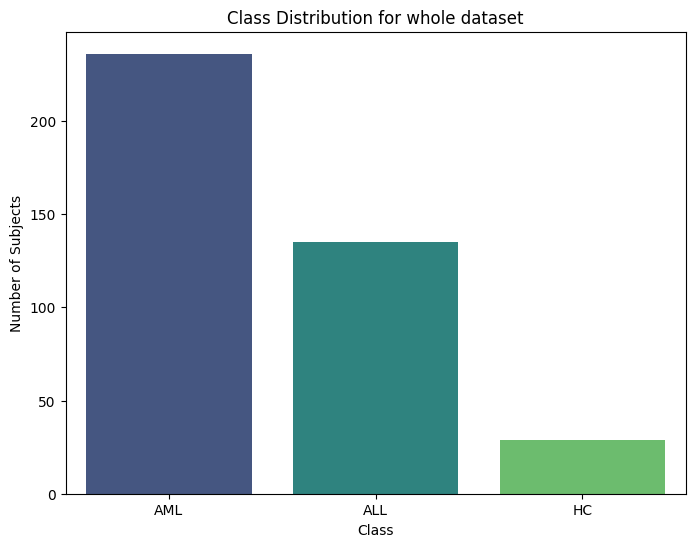

Class distribution for Training Set:
0    118
1     67
2     15
Name: count, dtype: int64

Class distribution for Validation Set:
0    118
1     68
2     14
Name: count, dtype: int64

Class distribution for Total Dataset:
0    236
1    135
2     29
Name: count, dtype: int64



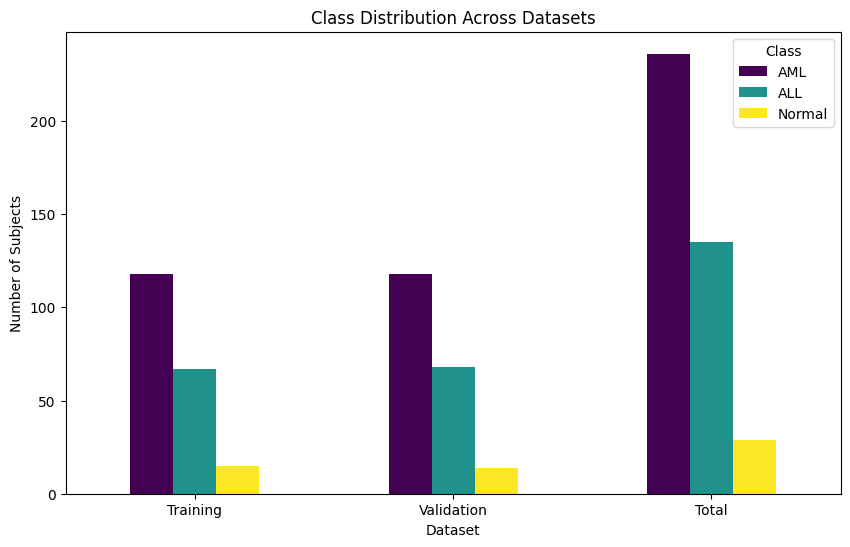

In [3]:
# Combine all data based on the toggle
if Toggle == "small":
    X_combined = np.vstack([X_train, X_val])  # Combine features
    y_combined = np.hstack([y_train, y_val])  # Combine labels
elif Toggle == "large":
    X_combined = np.vstack([X_train, X_val, X_test])  # Combine features
    y_combined = np.hstack([y_train, y_val, y_test])  # Combine labels

# Convert to pandas DataFrame for easier analysis
data_combined = pd.DataFrame(X_combined)
data_combined['label'] = y_combined

# Statistics
num_subjects = data_combined.shape[0]
num_features = data_combined.shape[1] - 1  # Exclude the label column
class_counts = data_combined['label'].value_counts()

print(f"Total number of subjects: {num_subjects}")
print(f"Total number of features: {num_features}")
print("Number of subjects in each class:")
print(class_counts)


# Bar plot for class distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution for whole dataset")
plt.xlabel("Class")
plt.ylabel("Number of Subjects")
plt.xticks(ticks=class_counts.index, labels=["AML", "ALL", "HC"])  # Adjust labels if needed
plt.show()

# Function to calculate and display class distribution
def display_class_distribution(y_data, dataset_name):
    class_counts = pd.Series(y_data).value_counts()
    print(f"Class distribution for {dataset_name}:")
    print(class_counts)
    print()

# Display class distribution for each dataset
display_class_distribution(y_train, "Training Set")
display_class_distribution(y_val, "Validation Set")
if Toggle == "large":
    display_class_distribution(y_test, "Test Set")
display_class_distribution(y_combined, "Total Dataset")

# Visualization of class distribution across datasets
datasets = ["Training", "Validation"]
class_distributions = [
    pd.Series(y_train).value_counts(),
    pd.Series(y_val).value_counts()
]

if Toggle == "large":
    datasets.append("Test")
    class_distributions.append(pd.Series(y_test).value_counts())

datasets.append("Total")
class_distributions.append(pd.Series(y_combined).value_counts())

# Combine distributions into a DataFrame for visualization
class_distribution_df = pd.DataFrame(class_distributions, index=datasets).fillna(0).astype(int)

# Bar plot for class distribution
class_distribution_df.plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.title("Class Distribution Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("Number of Subjects")
plt.legend(title="Class", labels=["AML", "ALL", "Normal"])
plt.xticks(rotation=0)
plt.show()


Normalization is applied to the data using Z-score normalization, and outliers are clipped to better fit with model assumptions (observations are assumed to be Gaussian distributed).

In [4]:
def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -10, 10)
    return X_clipped, X_train_mean, X_train_std

X_log = np.log1p(X_train)
X_norm, X_train_mean, X_train_std = normalize_data(X_log)

Data shape: (200, 400)
Label shape: (200,)
AML 118 ALL 67 Normal 15


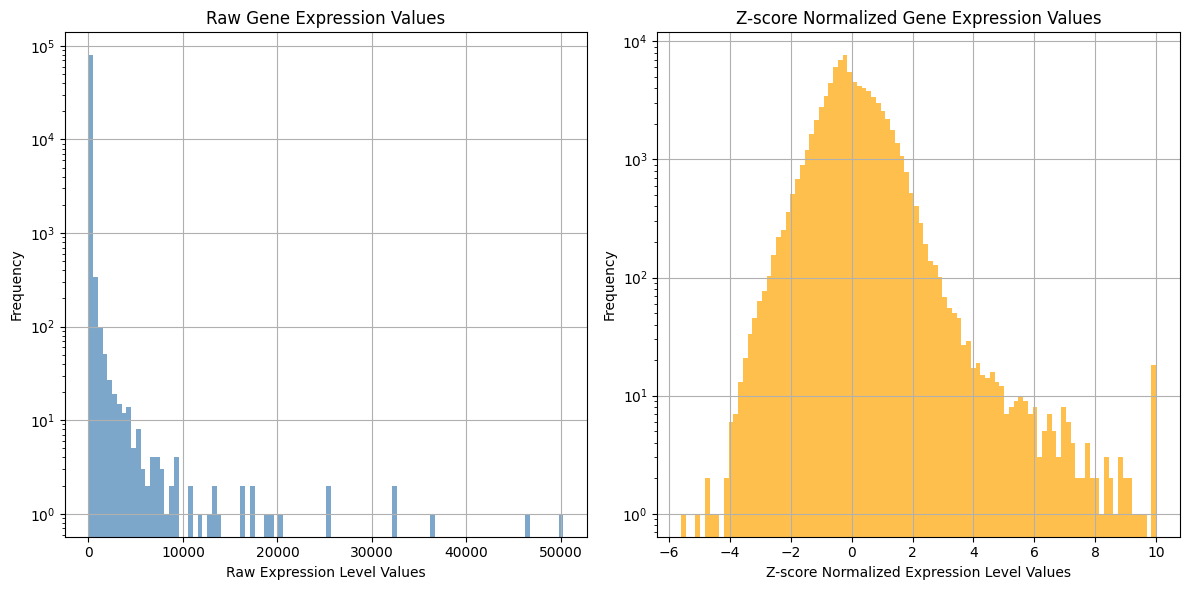

In [5]:
def present_data(data, label, norm_data):
    print("Data shape:", data.shape)
    print("Label shape:", label.shape)
    print(f"AML", np.sum(label == 0), "ALL", np.sum(label == 1), "Normal", np.sum(label == 2))

    # Flatten the matrix (5000 subjects × 60,000 genes) into a 1D array for plotting distribution
    raw_flat_gene_expr = data.flatten()
    norm_flat_gene_expr = norm_data.flatten()

    # Plot histograms of raw and normalized gene expression values
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(raw_flat_gene_expr, bins=100, color='steelblue', alpha=0.7)
    plt.title("Raw Gene Expression Values")
    plt.xlabel("Raw Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')
    plt.subplot(1, 2, 2)
    plt.hist(norm_flat_gene_expr, bins=100, color='orange', alpha=0.7)
    plt.title("Z-score Normalized Gene Expression Values")
    plt.xlabel("Z-score Normalized Expression Level Values")
    plt.ylabel("Frequency")
    plt.grid()
    plt.yscale('log')
    plt.tight_layout()
    plt.show()



present_data(X_train, y_train, X_norm)


<a id="model-definition-ppca-with-ard"></a>
## Supervised PPCA (SPPCA) with ARD

In [6]:
def supervised_ppca_model_linear(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    a0, b0 = torch.tensor(1e-1), torch.tensor(1e-1)
    alpha = pyro.sample("alpha", dist.Gamma(a0.expand(latent_dim), b0.expand(latent_dim)).to_event(1))

    # Loading matrix W with ARD prior (each latent factor scaled by α)
    W = pyro.sample("W", dist.Normal(torch.zeros(latent_dim, n_genes), alpha.unsqueeze(-1).rsqrt()).to_event(2))

    # Bayesian logistic regression parameters for classification head
    A = pyro.sample("A", dist.Normal(0., 1.).expand([n_classes, latent_dim]).to_event(2))
    b = pyro.sample("b", dist.Normal(0., 1.).expand([n_classes]).to_event(1))

    # Per-gene observation noise σ (model parameter)
    sigma = pyro.param("sigma_loc", torch.full((n_genes,), 0.1), constraint=dist.constraints.positive)

    # Generative process for each data sample
    with pyro.plate("data", n_samples):
        # Latent representation z per sample
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
    
        # Reconstruction of gene expression (observed data X)
        x_loc = torch.matmul(z, W)
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X)

        # Classification logits (linear model from latent variables)
        logits = torch.matmul(z, A.T) + b
        pyro.sample("y", dist.Categorical(logits=logits), obs=y)


def supervised_ppca_guide_linear(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape


    alpha_a = pyro.param("alpha_a", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha_b = pyro.param("alpha_b", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha = pyro.sample("alpha", dist.Gamma(alpha_a, alpha_b).to_event(1))

    # Variational posterior over loading matrix W
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes), constraint=dist.constraints.positive)
    pyro.sample("W", dist.Normal(w_loc, w_scale / alpha.unsqueeze(-1).sqrt()).to_event(2))

    # Variational posterior over classification parameters A and bias b
    A_loc = pyro.param("A_loc", torch.randn(n_classes, latent_dim))
    A_scale = pyro.param("A_scale", torch.ones(n_classes, latent_dim), constraint=dist.constraints.positive)
    pyro.sample("A", dist.Normal(A_loc, A_scale).to_event(2))

    b_loc = pyro.param("b_loc", torch.zeros(n_classes))
    b_scale = pyro.param("b_scale", torch.ones(n_classes), constraint=dist.constraints.positive)
    pyro.sample("b", dist.Normal(b_loc, b_scale).to_event(1))

    # Variational posterior for latent variables z
    z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim), constraint=dist.constraints.positive)

    with pyro.plate("data", n_samples):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))


<a id="training_SPPCA"></a>
## Training SPPCA with SVI

In [7]:
# Defining parameters for training SPPCA
latent_dim = 100
n_classes = 3

X_train_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

[Step 0] Loss: 4728034827.89
[Step 20] Loss: 21614010.72
[Step 40] Loss: 289076.19
[Step 60] Loss: 145918.11
[Step 80] Loss: 128097.63
[Step 100] Loss: 123785.63
[Step 120] Loss: 121978.06
[Step 140] Loss: 121659.09
[Step 160] Loss: 120260.02
[Step 180] Loss: 118366.51
[Step 200] Loss: 117459.12
[Step 220] Loss: 116051.10
[Step 240] Loss: 114574.27
[Step 260] Loss: 113210.89
[Step 280] Loss: 112221.74
[Step 300] Loss: 111476.40
[Step 320] Loss: 111165.53
[Step 340] Loss: 110214.93
[Step 360] Loss: 110366.88
[Step 380] Loss: 109780.32
[Step 400] Loss: 109817.37
[Step 420] Loss: 109832.17
[Step 440] Loss: 109956.34
[Step 460] Loss: 109108.94
[Step 480] Loss: 109811.51
[Step 500] Loss: 109248.97
[Step 520] Loss: 109410.25
[Step 540] Loss: 109680.56
[Step 560] Loss: 109815.22
[Step 580] Loss: 108867.73
[Step 600] Loss: 109216.00
[Step 620] Loss: 108588.76
[Step 640] Loss: 108544.37
[Step 660] Loss: 109824.22
[Step 680] Loss: 109141.95
[Step 700] Loss: 109724.19
[Step 720] Loss: 110742.14
[

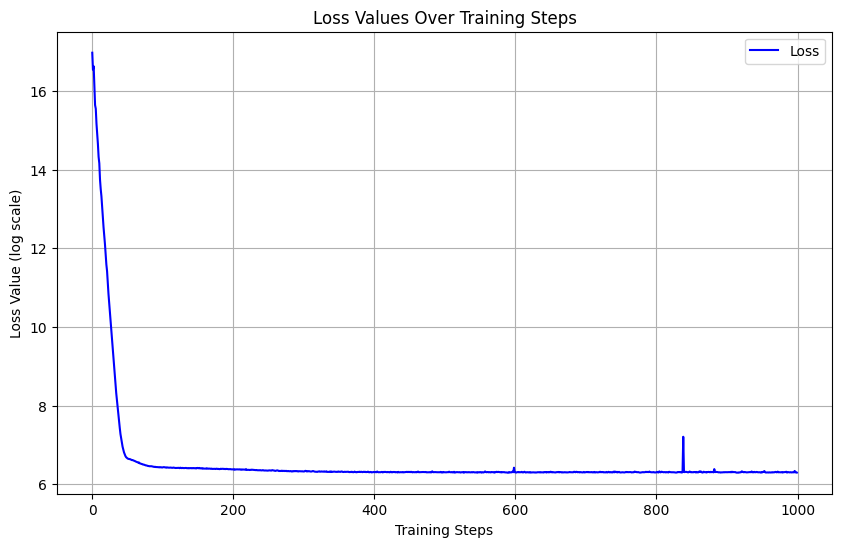

In [8]:
pyro.clear_param_store()

optimizer = ClippedAdam({"lr": 0.05})
svi = SVI(supervised_ppca_model_linear, supervised_ppca_guide_linear, optimizer, loss=Trace_ELBO())

start_time = time.time()
loss_values = []  # Array to store loss values

n_steps = SVI_PPCA_n_steps
for step in range(n_steps):
    loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
    loss_values.append(loss)  # Store the loss value
    if step % 20 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")

# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")

plt.figure(figsize=(10, 6))
plt.plot(np.log(np.array(loss_values)/len(X_train_tensor)), label="Loss", color="blue")
plt.xlabel("Training Steps")
plt.ylabel("Loss Value (log scale)")
plt.title("Loss Values Over Training Steps")
plt.legend()
plt.grid()
plt.show()

In [9]:
print(list(pyro.get_param_store().keys()))

['alpha_a', 'alpha_b', 'w_loc', 'w_scale', 'A_loc', 'A_scale', 'b_loc', 'b_scale', 'z_loc', 'z_scale', 'sigma_loc']


<a id="plotting_ARD"></a>
## Inspecting ARD Parameter

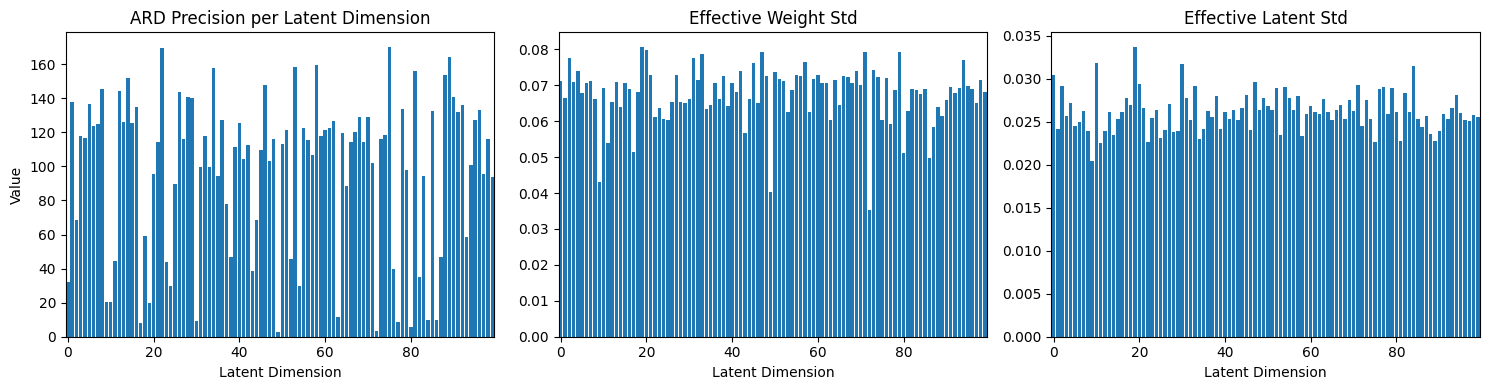

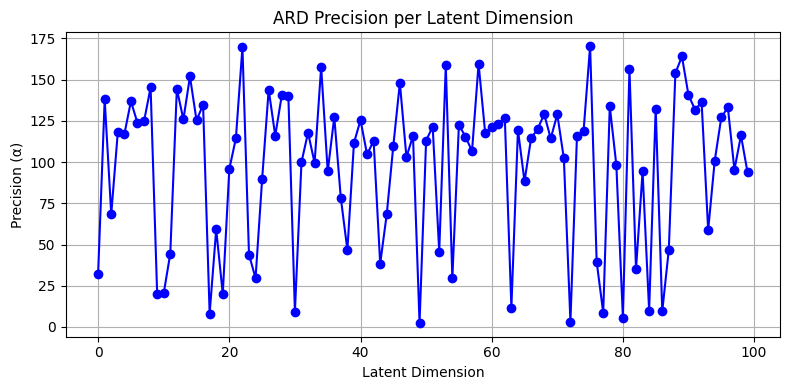

In [10]:
#1) Pull in and compute your ARD precision means
alpha_a = pyro.param("alpha_a").detach().cpu().numpy()
alpha_b = pyro.param("alpha_b").detach().cpu().numpy()
alpha_mean = alpha_a / alpha_b
latent_dim = alpha_mean.shape[0]

# 2) Effective W std (average over genes)
w_scale    = pyro.param("w_scale").detach().cpu().numpy()
w_eff_mean = (w_scale / np.sqrt(alpha_mean[:, None])).mean(axis=1)

# 3) Effective z std (average over samples)
z_scale    = pyro.param("z_scale").detach().cpu().numpy()
z_eff_mean = (z_scale / np.sqrt(alpha_mean)).mean(axis=0)

# 4) Now plot—all variables are defined
x     = np.arange(latent_dim)
width = 0.8  # data‐unit width

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

axes[0].bar(x, alpha_mean,   width=width, align="center")
axes[0].set(title="ARD Precision per Latent Dimension", ylabel="Value")

axes[1].bar(x, w_eff_mean,   width=width, align="center")
axes[1].set(title="Effective Weight Std")

axes[2].bar(x, z_eff_mean,   width=width, align="center")
axes[2].set(title="Effective Latent Std")

for ax in axes:
    ax.set_xlabel("Latent Dimension")
    ax.set_xlim(-0.5, latent_dim - 0.5)

plt.tight_layout()
plt.show()

# plot of alpha_mean
plt.figure(figsize=(8, 4))
plt.plot(alpha_mean, marker='o', linestyle='-', color='b')
plt.title("ARD Precision per Latent Dimension")
plt.xlabel("Latent Dimension")
plt.ylabel("Precision (α)")
plt.grid()
plt.tight_layout()
plt.show()

<a id="inspecting_latent_space"></a>
## Inspecting Latent Space

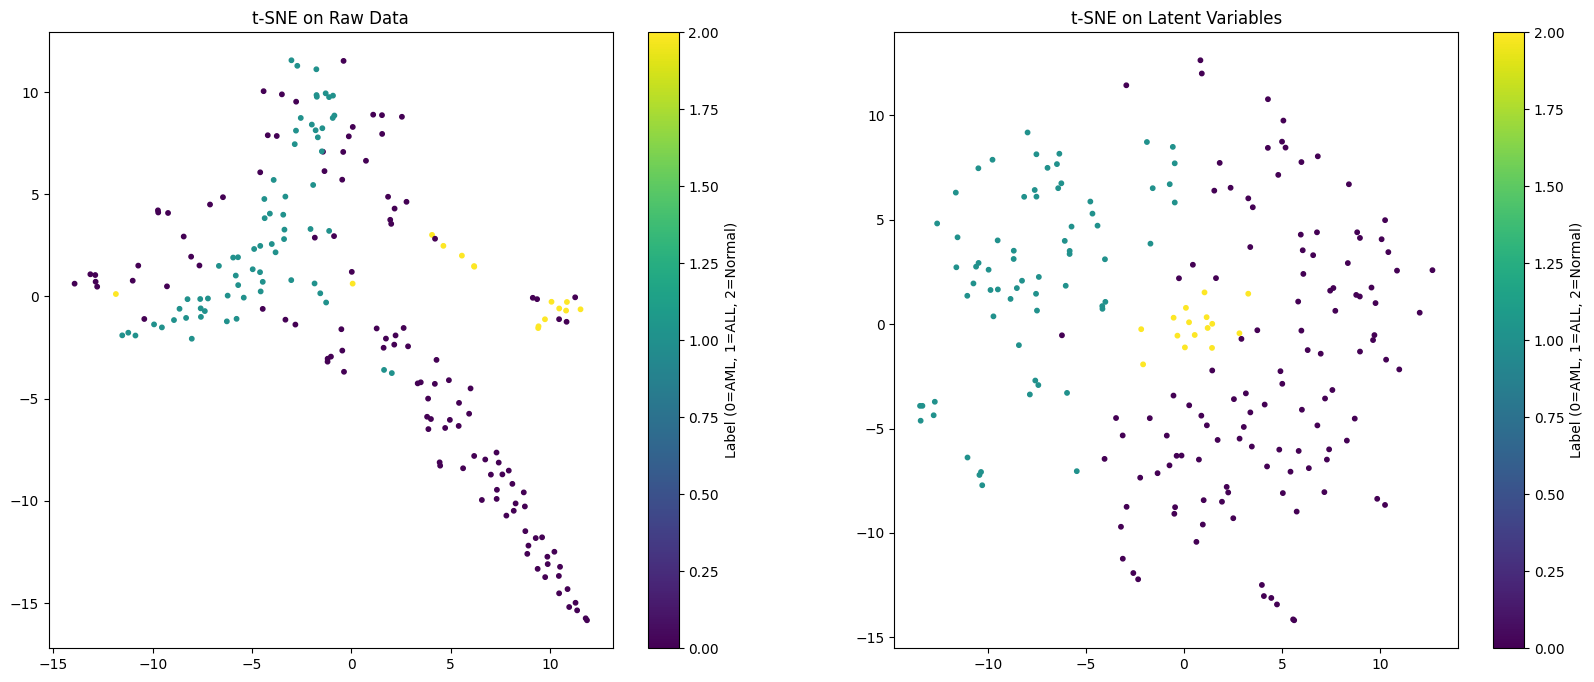

In [11]:
def TSNE_plots(z_loc, labels):
    raw_data_tsne = TSNE(n_components=2).fit_transform(X_train)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()

z_loc = pyro.param("z_loc").detach()
TSNE_plots(z_loc, y_train)


<a id="classi_test"></a>
## Performing Classification on Test Data

In [ ]:
if Toggle == "large":
 
    # --- 1) Load test data and normalize it ---
    X_test_norm = normalize_data(np.log1p(X_test))[0]
    X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)

 
    # --- 2) Load parameters from the trained model ---
    ps = pyro.get_param_store()
    W_pm = ps["w_loc"].detach()                    # [latent_dim, n_genes]
    sigma_pm = ps["sigma_loc"].detach()                # [n_genes]
    A_pm = ps["A_loc"].detach()                    # [n_classes, latent_dim]
    b_pm = ps["b_loc"].detach()                    # [n_classes]




    # --- 3) Unsupervised PPCA “model” that only generates X under locked parameters ---
    def infer_z_model(X):
        N = X.shape[0]

        with pyro.plate("data", N):
            # ARD‐scaled prior on z
            z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
            # likelihood for X under fixed W, sigma
            x_loc = torch.matmul(z, W_pm)                     # [N_val, n_genes]
            pyro.sample("x", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X)

    def infer_z_guide(X):
        N = X.shape[0]

        z_loc   = pyro.param("z_loc_test", torch.randn(N, latent_dim))
        z_scale = pyro.param("z_scale_test", torch.ones(N, latent_dim), constraint=dist.constraints.positive)
        with pyro.plate("data", N):
            pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))


    # --- 4) Inference on the test set ---
    # without clearing the param store, we can use the parameters learned from the training phase
    optimizer_inf = ClippedAdam({"lr": 0.05})
    svi_inf       = SVI(infer_z_model, infer_z_guide, optimizer_inf, loss=Trace_ELBO())

    start = time.time()
    n_steps = SVI_z_n_steps
    for step in range(n_steps):
        loss = svi_inf.step(X_test_tensor)
        if step % 20 == 0:
            print(f"[val step {step}] loss = {loss:.1f}")


    print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


    # --- 5) Extract the latent variables z from the test set ---
    z_loc_test = pyro.param("z_loc_test").detach()   # [n_samples, latent_dim]


    # --- 6) Predict classes from the latent variables z using the linear relation of latent space z to labels y ---
    def predict_classes(z_loc, A, b, y_true):
        # Compute logits and probabilities
        logits = torch.matmul(z_loc, A.T) + b
        probs = torch.softmax(logits, dim=-1)
        y_hat = dist.Categorical(probs=probs).sample().cpu().numpy()

        # Compute accuracy
        y_true = np.array(y_true)
        accuracy = (y_true == y_hat).mean()
        print(f"Validation Accuracy: {accuracy:.4f}")

        # Confusion matrix
        conf_matrix = confusion_matrix(y_true, y_hat)
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            conf_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["AML", "ALL", "Normal"],
            yticklabels=["AML", "ALL", "Normal"]
        )
        plt.xlabel("Predicted Labels")
        plt.ylabel("True Labels")
        plt.title("Confusion Matrix")
        plt.show()

        print("Classification Report from Latent Space:")
        print(classification_report(y_true, y_hat))

        return y_hat

    y_hat_val = predict_classes(z_loc_test, A_pm, b_pm, y_test)


else:
    print("Skipping prediction step for small dataset as no test set is available.")  

Skipping prediction step for small dataset as no test set is available.


<a id="classi_val"></a>
## Performing Classification on Validation Data

Validation data is normalized and conveted to a tensor.

In [13]:
X_val_norm = normalize_data(np.log1p(X_val))[0]
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)

We use the weights and parameters (matrix W_pm and noise sigma_pm) that were learned during SPPCA training on the training data. Then, we project the new data into the latent space by inferring only the latent variables z for the validation samples, treating the model as a PPCA with fixed parameters.

X data is treated as an observed variable and so is the latent dim weights W_pm, while the latent variables z are treated as unobserved variables.



In [14]:
ps = pyro.get_param_store()
W_pm = ps["w_loc"].detach()                    # [latent_dim, n_genes]
sigma_pm = ps["sigma_loc"].detach()                # scalar or [n_genes]
A_pm = ps["A_loc"].detach()                    # [n_classes, latent_dim]
b_pm = ps["b_loc"].detach()                    # [n_classes]

In [ ]:
# --- ) Unsupervised PPCA “model” that only generates X under locked parameters ---
def infer_z_val_model(X):
    N = X.shape[0]

    with pyro.plate("data", N):
        # ARD‐scaled prior on z
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        # likelihood for X under fixed W, sigma
        x_loc = torch.matmul(z, W_pm)                     # [N_val, n_genes]
        pyro.sample("x", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X)

# --- 2) Guide that only learns z_loc_val / z_scale_val ---
def infer_z_val_guide(X):
    N = X.shape[0]

    z_loc   = pyro.param("z_loc_val", torch.randn(N, latent_dim))
    z_scale = pyro.param("z_scale_val", torch.ones(N, latent_dim), constraint=dist.constraints.positive)
    with pyro.plate("data", N):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

# --- 3) Run SVI on X only to infer z_loc_val / z_scale_val ---
# (do NOT clear the ParamStore here if you want to keep W_pm etc.)
optimizer_inf = ClippedAdam({"lr": 0.05})
svi_inf       = SVI(infer_z_val_model, infer_z_val_guide, optimizer_inf, loss=Trace_ELBO())

start = time.time()
n_steps = SVI_z_n_steps
for step in range(n_steps):
    loss = svi_inf.step(X_val_tensor)
    if step % 20 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")


print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


[val step 0] loss = 738199.9
[val step 20] loss = 306232.6
[val step 40] loss = 150318.1
[val step 60] loss = 102165.8
[val step 80] loss = 84871.0
[val step 100] loss = 81093.8
[val step 120] loss = 79824.9
[val step 140] loss = 79781.6
[val step 160] loss = 79738.4
[val step 180] loss = 79561.9
[val step 200] loss = 79588.0
[val step 220] loss = 79760.9
[val step 240] loss = 79667.8
[val step 260] loss = 79583.6
[val step 280] loss = 79684.0
[val step 300] loss = 79664.5
[val step 320] loss = 79709.6
[val step 340] loss = 79771.0
[val step 360] loss = 79917.8
[val step 380] loss = 79728.4
[val step 400] loss = 79708.5
[val step 420] loss = 79903.8
[val step 440] loss = 79713.4
[val step 460] loss = 79852.1
[val step 480] loss = 79815.9
[val step 500] loss = 79819.1
[val step 520] loss = 79785.2
[val step 540] loss = 79779.4
[val step 560] loss = 79806.1
[val step 580] loss = 80038.9
[val step 600] loss = 79825.2
[val step 620] loss = 79858.3
[val step 640] loss = 79836.0
[val step 66

In [16]:
# --- 5) Prediction function ---
def predict_classes(z_loc, A, b, y_true):
    # Compute logits and probabilities
    logits = torch.matmul(z_loc, A.T) + b
    probs = torch.softmax(logits, dim=-1)
    y_hat = dist.Categorical(probs=probs).sample().cpu().numpy()

    # Compute accuracy
    y_true = np.array(y_true)
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["AML", "ALL", "Normal"],
        yticklabels=["AML", "ALL", "Normal"]
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    print("Classification Report from Latent Space:")
    print(classification_report(y_true, y_hat))

    return y_hat

Validation Accuracy: 0.9350


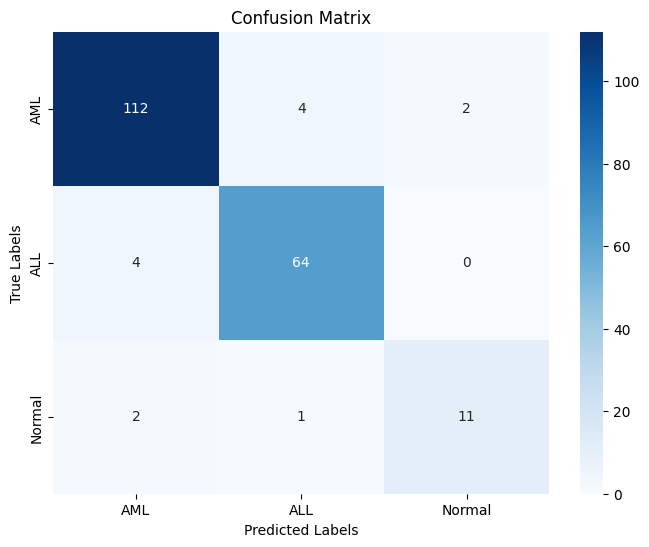

Classification Report from Latent Space:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       118
           1       0.93      0.94      0.93        68
           2       0.85      0.79      0.81        14

    accuracy                           0.94       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.93      0.94      0.93       200



In [17]:
z_loc_val = pyro.param("z_loc_val").detach()   # [n_val_samples, latent_dim]
y_hat_val = predict_classes(z_loc_val, A_pm, b_pm, y_val)

<a id="feature_importance"></a>
## Visualizing Feature Importance

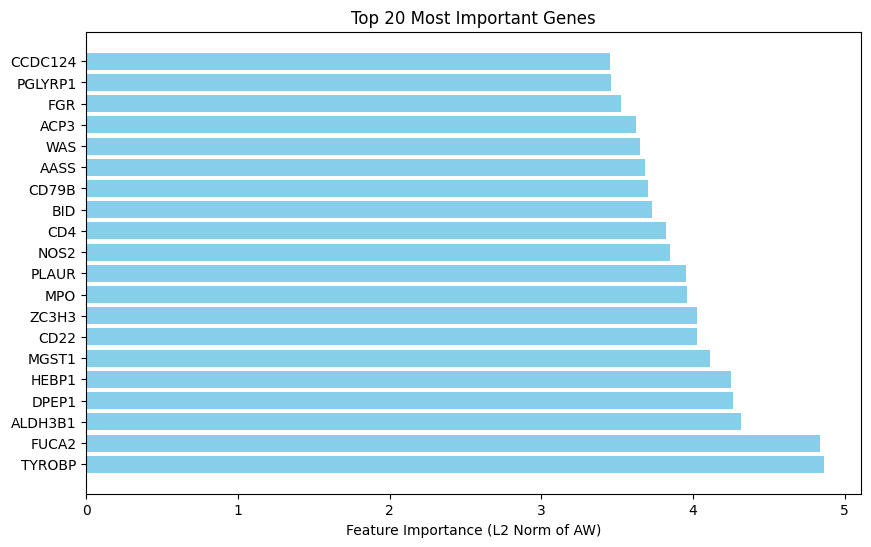

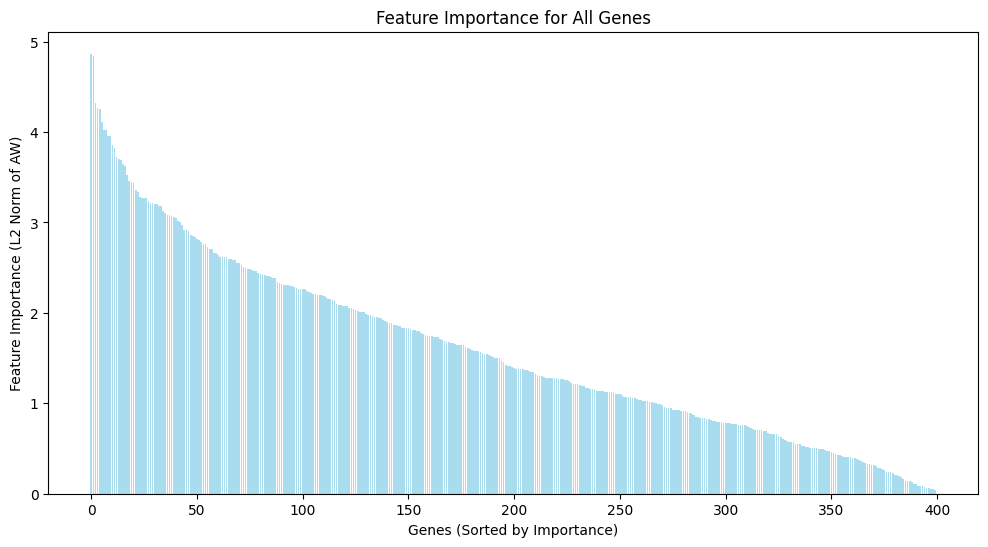

In [18]:
# Example usage
W = pyro.param("w_loc").detach().cpu().numpy()  # Shape: [latent_dim, n_genes]
A = A_pm.detach().cpu().numpy()                # Shape: [n_classes, latent_dim]
top_n = 20

# Compute feature importance
gene_importance, top_indices, top_importance = compute_feature_importance_from_AW(W, A, alpha_mean, top_n=top_n)

# Plot the top genes
plot_top_genes_from_AW(top_indices, top_importance, top_n=top_n, gene_names=gene_names)
plot_all_genes_from_AW(gene_importance)

## SPPCA using NN for label classification

In [19]:
def supervised_ppca_model_nn(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # ARD prior for latent dimensions
    a0, b0 = torch.tensor(1e-1), torch.tensor(1e-1)
    alpha = pyro.sample("alpha", dist.Gamma(a0.expand(latent_dim), b0.expand(latent_dim)).to_event(1))

    # Loading matrix W with ARD prior
    W = pyro.sample("W", dist.Normal(torch.zeros(latent_dim, n_genes), alpha.unsqueeze(-1).rsqrt()).to_event(2))

    # Per-gene observation noise σ
    sigma = pyro.param("sigma_loc", torch.full((n_genes,), 0.1), constraint=dist.constraints.positive)

    # Define a nonlinear neural network for classification
    hidden_dim = 64  # Example hidden layer size
    nn_weights_1 = pyro.param("nn_weights_1", torch.randn(latent_dim, hidden_dim))
    nn_bias_1 = pyro.param("nn_bias_1", torch.zeros(hidden_dim))
    nn_weights_2 = pyro.param("nn_weights_2", torch.randn(hidden_dim, n_classes))
    nn_bias_2 = pyro.param("nn_bias_2", torch.zeros(n_classes))

    # Generative process for each data sample
    with pyro.plate("data", n_samples):
        # Latent representation z per sample
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))

        # Reconstruction of gene expression (observed data X)
        x_loc = torch.matmul(z, W)
        pyro.sample("obs", dist.Normal(x_loc, sigma).to_event(1), obs=X)

        # Nonlinear classification logits using a neural network
        hidden = torch.relu(torch.matmul(z, nn_weights_1) + nn_bias_1)
        logits = torch.matmul(hidden, nn_weights_2) + nn_bias_2
        pyro.sample("y", dist.Categorical(logits=logits), obs=y)


def supervised_ppca_guide_nn(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape
    hidden_dim = 64

    # ARD precision parameters
    alpha_a = pyro.param("alpha_a", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha_b = pyro.param("alpha_b", torch.ones(latent_dim), constraint=dist.constraints.positive)
    alpha = pyro.sample("alpha", dist.Gamma(alpha_a, alpha_b).to_event(1))

    # Variational posterior for W
    w_loc = pyro.param("w_loc", torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale", torch.ones(latent_dim, n_genes), constraint=dist.constraints.positive)
    pyro.sample("W", dist.Normal(w_loc, w_scale / alpha.unsqueeze(-1).sqrt()).to_event(2))

    # Variational posterior for neural network parameters
    nn_weights_1_loc = pyro.param("nn_weights_1_loc", torch.randn(latent_dim, hidden_dim))
    nn_weights_1_scale = pyro.param("nn_weights_1_scale", torch.ones(latent_dim, hidden_dim), constraint=dist.constraints.positive)
    pyro.sample("nn_weights_1", dist.Normal(nn_weights_1_loc, nn_weights_1_scale).to_event(2))

    nn_bias_1_loc = pyro.param("nn_bias_1_loc", torch.zeros(hidden_dim))
    nn_bias_1_scale = pyro.param("nn_bias_1_scale", torch.ones(hidden_dim), constraint=dist.constraints.positive)
    pyro.sample("nn_bias_1", dist.Normal(nn_bias_1_loc, nn_bias_1_scale).to_event(1))

    nn_weights_2_loc = pyro.param("nn_weights_2_loc", torch.randn(hidden_dim, n_classes))
    nn_weights_2_scale = pyro.param("nn_weights_2_scale", torch.ones(hidden_dim, n_classes), constraint=dist.constraints.positive)
    pyro.sample("nn_weights_2", dist.Normal(nn_weights_2_loc, nn_weights_2_scale).to_event(2))

    nn_bias_2_loc = pyro.param("nn_bias_2_loc", torch.zeros(n_classes))
    nn_bias_2_scale = pyro.param("nn_bias_2_scale", torch.ones(n_classes), constraint=dist.constraints.positive)
    pyro.sample("nn_bias_2", dist.Normal(nn_bias_2_loc, nn_bias_2_scale).to_event(1))

    # Variational posterior for z
    z_loc = pyro.param("z_loc", torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale", torch.ones(n_samples, latent_dim), constraint=dist.constraints.positive)
    with pyro.plate("data", n_samples):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

In [20]:
pyro.clear_param_store()

optimizer = ClippedAdam({"lr": 0.01})
svi = SVI(supervised_ppca_model_nn, supervised_ppca_guide_nn, optimizer, loss=Trace_ELBO())

start_time = time.time()

n_steps = SVI_PPCA_n_steps
for step in range(n_steps):
    loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
    if step % 20 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")

# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")

c:\Users\kgl07\anaconda3\envs\course42186\Lib\site-packages\pyro\util.py:288: UserWarning: Found non-auxiliary vars in guide but not model, consider marking these infer={'is_auxiliary': True}:
{'nn_bias_1', 'nn_weights_2', 'nn_weights_1', 'nn_bias_2'}
  warnings.warn(


[Step 0] Loss: 4850583114.15
[Step 20] Loss: 1130686696.16
[Step 40] Loss: 400687762.02
[Step 60] Loss: 158570620.89
[Step 80] Loss: 49208944.87
[Step 100] Loss: 16718691.76
[Step 120] Loss: 5825289.20
[Step 140] Loss: 2060568.15
[Step 160] Loss: 794582.11
[Step 180] Loss: 345533.97
[Step 200] Loss: 182720.67
[Step 220] Loss: 130807.07
[Step 240] Loss: 112985.01
[Step 260] Loss: 103507.01
[Step 280] Loss: 96410.15
[Step 300] Loss: 89998.25
[Step 320] Loss: 85939.76
[Step 340] Loss: 81829.43
[Step 360] Loss: 80354.30
[Step 380] Loss: 77292.19
[Step 400] Loss: 75809.33
[Step 420] Loss: 73244.75
[Step 440] Loss: 71551.07
[Step 460] Loss: 70085.24
[Step 480] Loss: 68617.63
[Step 500] Loss: 66142.97
[Step 520] Loss: 65046.53
[Step 540] Loss: 63282.01
[Step 560] Loss: 61824.00
[Step 580] Loss: 60305.02
[Step 600] Loss: 58645.57
[Step 620] Loss: 56500.92
[Step 640] Loss: 55426.87
[Step 660] Loss: 53602.32
[Step 680] Loss: 51968.50
[Step 700] Loss: 50690.25
[Step 720] Loss: 49483.88
[Step 740]

In [21]:
# --- 1) Unsupervised PPCA “model” that only generates X under locked params ---
def infer_z_nn_model(X):
    N = X.shape[0]

    with pyro.plate("data", N):
        # ARD-scaled prior on z
        z = pyro.sample("z", dist.Normal(0., 1.).expand([latent_dim]).to_event(1))
        
        # Reconstruction of gene expression (observed data X)
        x_loc = torch.matmul(z, W_pm)  # Reconstruction using W_pm
        pyro.sample("x", dist.Normal(x_loc, sigma_pm).to_event(1), obs=X)

# --- 2) Guide that only learns z_loc_val / z_scale_val ---
def infer_z_nn_guide(X):
    N = X.shape[0]

    # Variational parameters for z
    z_loc = pyro.param("z_loc_nn", torch.randn(N, latent_dim))  # Mean of z
    z_scale = pyro.param("z_scale_nn", torch.ones(N, latent_dim), constraint=dist.constraints.positive)  # Scale of z

    with pyro.plate("data", N):
        # Variational posterior for z
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

# --- 3) Run SVI on X only to infer z_loc_val / z_scale_val ---
# (do NOT clear the ParamStore here if you want to keep W_pm etc.)
optimizer_inf = ClippedAdam({"lr": 0.05})
svi_inf       = SVI(infer_z_nn_model, infer_z_nn_guide, optimizer_inf, loss=Trace_ELBO())

start = time.time()
n_steps = SVI_z_n_steps
for step in range(n_steps):
    loss = svi_inf.step(X_val_tensor)
    if step % 20 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")


print(f"Total time spent: {time.time() - start_time:.2f} seconds ({((time.time() - start_time) / 60):.2f} minutes)")


[val step 0] loss = 770207.7
[val step 20] loss = 312012.5
[val step 40] loss = 154203.5
[val step 60] loss = 106768.3
[val step 80] loss = 85498.3
[val step 100] loss = 81128.9
[val step 120] loss = 80122.6
[val step 140] loss = 79768.9
[val step 160] loss = 79620.3
[val step 180] loss = 79636.2
[val step 200] loss = 79611.6
[val step 220] loss = 79646.9
[val step 240] loss = 79662.5
[val step 260] loss = 79460.8
[val step 280] loss = 79769.1
[val step 300] loss = 79760.9
[val step 320] loss = 79722.1
[val step 340] loss = 79634.6
[val step 360] loss = 79702.6
[val step 380] loss = 79725.8
[val step 400] loss = 79708.3
[val step 420] loss = 79797.9
[val step 440] loss = 79841.2
[val step 460] loss = 79851.0
[val step 480] loss = 79864.6
[val step 500] loss = 79802.2
[val step 520] loss = 79763.7
[val step 540] loss = 79803.7
[val step 560] loss = 79685.6
[val step 580] loss = 79824.6
[val step 600] loss = 79880.5
[val step 620] loss = 79715.6
[val step 640] loss = 79758.8
[val step 66

In [22]:
# Neural network parameters (assumed to be learned during training)
nn_weights_1 = pyro.param("nn_weights_1").detach()  # Shape: [latent_dim, hidden_dim]
nn_bias_1 = pyro.param("nn_bias_1").detach()        # Shape: [hidden_dim]
nn_weights_2 = pyro.param("nn_weights_2").detach()  # Shape: [hidden_dim, n_classes]
nn_bias_2 = pyro.param("nn_bias_2").detach()        # Shape: [n_classes]

Validation Accuracy: 0.4450


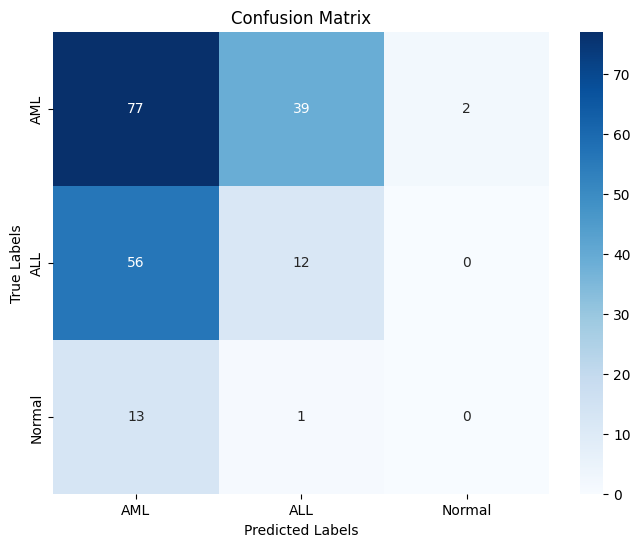

Classification Report from Neural Network:
              precision    recall  f1-score   support

           0       0.53      0.65      0.58       118
           1       0.23      0.18      0.20        68
           2       0.00      0.00      0.00        14

    accuracy                           0.45       200
   macro avg       0.25      0.28      0.26       200
weighted avg       0.39      0.45      0.41       200



In [23]:
z_loc_nn = pyro.param("z_loc_nn").detach()   # [n_val_samples, latent_dim]

def predict_classes_nn(z_loc, nn_weights_1, nn_bias_1, nn_weights_2, nn_bias_2, y_true):
    # Compute hidden layer activations
    hidden = torch.relu(torch.matmul(z_loc, nn_weights_1) + nn_bias_1)
    
    # Compute logits using the second layer
    logits = torch.matmul(hidden, nn_weights_2) + nn_bias_2
    
    # Predict class labels
    y_hat = torch.argmax(logits, dim=-1).cpu().numpy()

    # Compute accuracy
    y_true = np.array(y_true)
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["AML", "ALL", "Normal"],
        yticklabels=["AML", "ALL", "Normal"]
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    print("Classification Report from Neural Network:")
    print(classification_report(y_true, y_hat))

    return y_hat

y_hat = predict_classes_nn(z_loc_nn, nn_weights_1, nn_bias_1, nn_weights_2, nn_bias_2, y_val)
